In [1]:
import udkm1Dsim as ud
u = ud.u  # import the pint unit registry from udkm1Dsim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
u.setup_matplotlib()  # use matplotlib with pint units

In [2]:
Cr = ud.Atom('Cr')
Si = ud.Atom('Si')

In [3]:
density_Cr = 7140*u.kg/u.m**3

prop_Cr = {}
prop_Cr['heat_capacity'] = 449*u.J/u.kg/u.K
prop_Cr['therm_cond'] = 94*u.W/(u.m*u.K)
prop_Cr['lin_therm_exp'] = 6.2e-6
prop_Cr['sound_vel'] = 5.940*u.nm/u.ps
prop_Cr['opt_ref_index'] = 3.1612+3.4606j
prop_Cr['opt_ref_index_per_strain'] = 0+0j

layer_Cr = ud.AmorphousLayer('Cr', "Cr amorphous", 10*u.nm, density_Cr/3, atom=Cr, **prop_Cr)

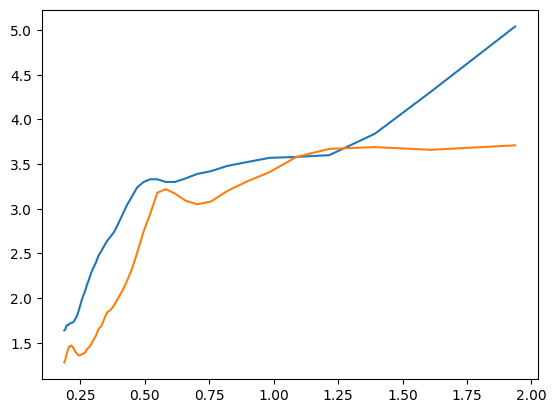

In [4]:
Cr_wl, Cr_n, Cr_k = np.loadtxt('Cr.nk', unpack=True)

plt.figure()

plt.plot(Cr_wl, Cr_k)
plt.plot(Cr_wl, Cr_n)

plt.show()

layer_Cr.opt_ref_index_wl = Cr_wl
layer_Cr.opt_ref_index_nk = Cr_n + 1j*Cr_k


In [5]:
layer_Cr.opt_ref_index_nk 

array([1.28+1.64j, 1.31+1.65j, 1.35+1.68j, 1.39+1.7j , 1.43+1.7j ,
       1.46+1.71j, 1.46+1.72j, 1.47+1.72j, 1.45+1.73j, 1.43+1.74j,
       1.4 +1.77j, 1.38+1.8j , 1.36+1.85j, 1.36+1.91j, 1.37+1.97j,
       1.38+2.03j, 1.39+2.08j, 1.43+2.15j, 1.45+2.21j, 1.48+2.28j,
       1.53+2.34j, 1.58+2.4j , 1.65+2.47j, 1.69+2.53j, 1.76+2.58j,
       1.84+2.64j, 1.87+2.69j, 1.92+2.74j, 2.  +2.83j, 2.08+2.93j,
       2.19+3.04j, 2.33+3.14j, 2.51+3.24j, 2.75+3.3j , 2.94+3.33j,
       3.18+3.33j, 3.22+3.3j , 3.17+3.3j , 3.09+3.34j, 3.05+3.39j,
       3.08+3.42j, 3.2 +3.48j, 3.3 +3.52j, 3.41+3.57j, 3.58+3.58j,
       3.67+3.6j , 3.69+3.84j, 3.66+4.31j, 3.71+5.04j])

In [6]:
density_Si = 2336*u.kg/u.m**3

prop_Si = {}
prop_Si['heat_capacity'] = 703*u.J/u.kg/u.K
prop_Si['therm_cond'] = 150*u.W/(u.m*u.K)
prop_Si['lin_therm_exp'] = 2.6e-6
prop_Si['sound_vel'] = 8.433*u.nm/u.ps
prop_Si['opt_ref_index'] = 3.6941+0j
prop_Si['opt_ref_index_per_strain'] = 1+0j

layer_Si = ud.AmorphousLayer('Si', "Si amorphous", 10*u.nm, density_Si, atom=Si, **prop_Si)

In [7]:
S = ud.Structure('Fe/Cr AFM Super Lattice')

S.add_sub_structure(layer_Cr, 10)
S.add_sub_structure(layer_Si, 500)

substrate = ud.Structure('substrate')
substrate.add_sub_structure(layer_Si, 5000)

S.add_substrate(substrate)

In [8]:
h = ud.Heat(S, True)

h.save_data = False
h.disp_messages = True

h.excitation = {'fluence': [40]*u.mJ/u.cm**2,
                'delay_pump':  [0]*u.ps,
                'pulse_width':  [1]*u.ps,
                'multilayer_absorption': True,
                'wavelength': 800*u.nm,
                'theta': 45*u.deg}

# enable heat diffusion
h.heat_diffusion = True

# temporal and spatial grid
delays = np.r_[-2:400:1]*u.ps
_, _, distances = S.get_distances_of_layers()

In [9]:
temp_map, delta_temp_map = h.get_temp_map(delays, 0*u.K)

Surface incidence fluence scaled by factor 0.7071 due to incidence angle theta=45.00 deg
Calculating _heat_diffusion_ for excitation 1:1 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 45.0 % and transmission of 0.4 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 4.101583 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 3.191281 s
Elapsed time for _temp_map_: 7.364140 s


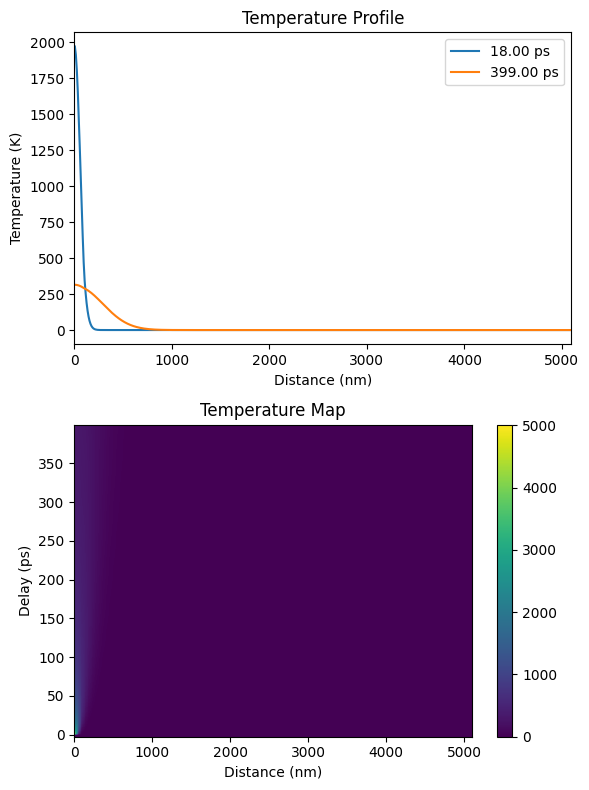

In [10]:
plt.figure(figsize=[6, 8])
plt.subplot(2, 1, 1)
plt.plot(distances.to('nm').magnitude, temp_map[20, :],
         label='{:0.2f} ps'.format(delays[20].to('ps').magnitude))
plt.plot(distances.to('nm').magnitude, temp_map[-1, :],
         label='{:0.2f} ps'.format(delays[-1].to('ps').magnitude))
plt.xlim([0, distances.to('nm').magnitude[-1]])
plt.xlabel('Distance (nm)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.title('Temperature Profile')

plt.subplot(2, 1, 2)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, temp_map, shading='auto')
plt.colorbar()
plt.xlabel('Distance (nm)')
plt.ylabel('Delay (ps)')
plt.title('Temperature Map')

plt.tight_layout()
plt.show()

In [11]:
p = ud.PhononNum(S, True)
p.save_data = False
p.disp_messages = True

In [12]:
strain_map = p.get_strain_map(delays, temp_map, delta_temp_map)

Calculating linear thermal expansion ...
Calculating coherent dynamics with ODE solver ...


0it [00:00, ?it/s]

Elapsed time for _strain_map_: 0.208772 s


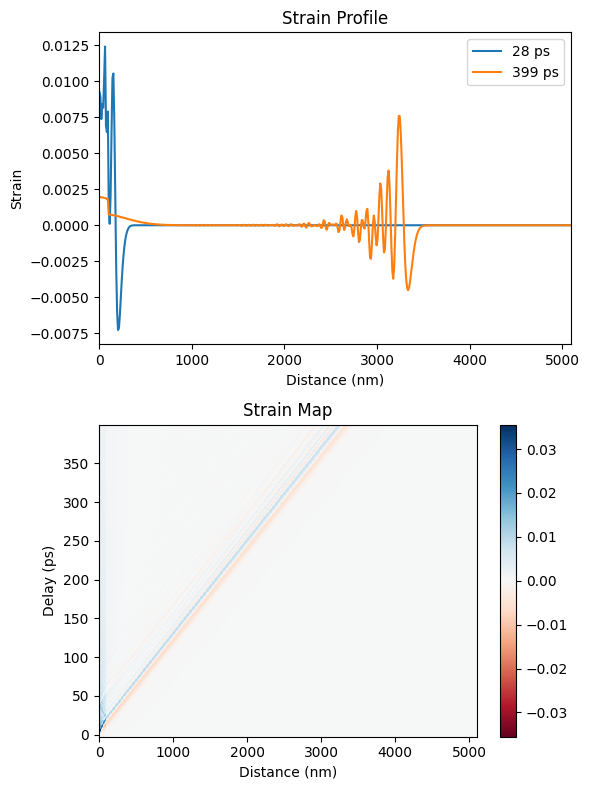

In [13]:
plt.figure(figsize=[6, 8])
plt.subplot(2, 1, 1)
plt.plot(distances.to('nm').magnitude, strain_map[30, :], label=np.round(delays[30]))
plt.plot(distances.to('nm').magnitude, strain_map[-1, :], label=np.round(delays[-1]))
plt.xlim([0, distances.to('nm').magnitude[-1]])
plt.xlabel('Distance (nm)')
plt.ylabel('Strain')
plt.legend()
plt.title('Strain Profile')

plt.subplot(2, 1, 2)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude,
               strain_map, cmap='RdBu', vmin=-np.max(strain_map),
               vmax=np.max(strain_map), shading='auto')
plt.colorbar()
plt.xlabel('Distance (nm)')
plt.ylabel('Delay (ps)')
plt.title('Strain Map')

plt.tight_layout()
plt.show()

In [14]:
light = ud.Light(S, True)
light.disp_messages = True
light.save_data = False
# light.set_incoming_polarization(3)

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized


In [15]:
light.energy = np.r_[0.5:3:0.01]*u.eV  # set two photon energies
light.theta = np.r_[1:90:1]*u.deg  # theta range
# this is the actual calculation
R, T = light.homogeneous_reflectivity()

In [16]:
T.shape

(250, 89)

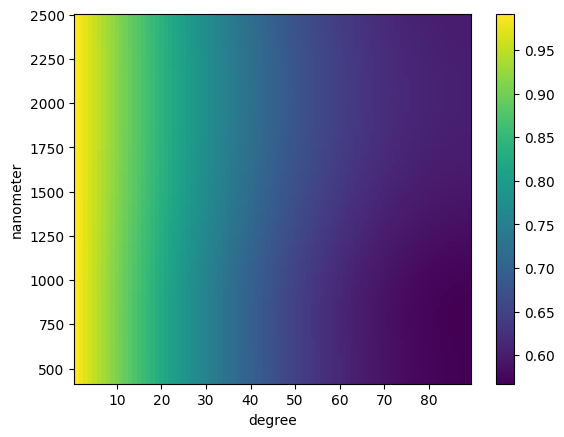

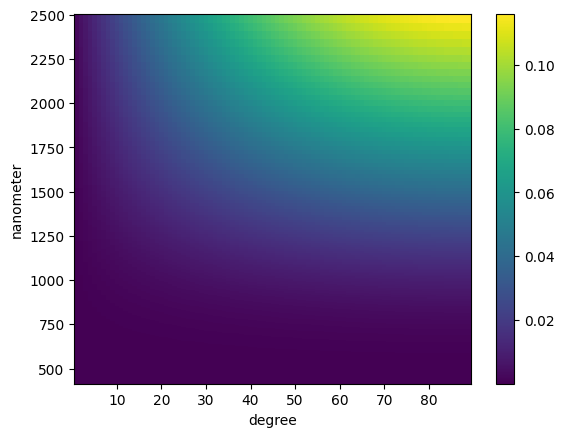

In [17]:
plt.figure()
plt.pcolormesh(light.theta[0, :], light.wl, R)
plt.colorbar()
plt.show()

plt.figure()
plt.pcolormesh(light.theta[0, :], light.wl, T)
plt.colorbar()
plt.show()

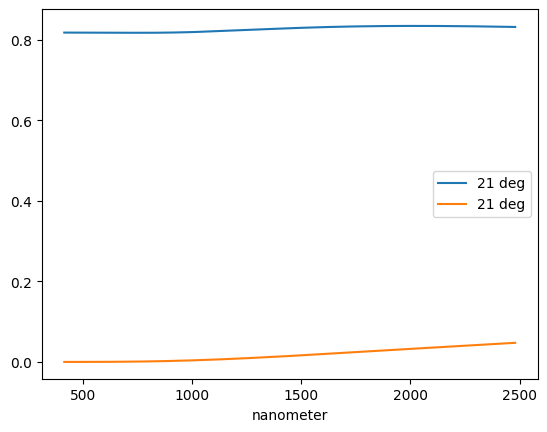

In [18]:
plt.figure()
idx = 20
plt.plot(light.wl, R[:, idx], label=light.theta[0, idx])
plt.plot(light.wl, T[:, idx], label=light.theta[0, idx])
plt.legend()
plt.show()

In [19]:
light.energy = np.r_[0.5:3:0.01]*u.eV  # set two photon energies
light.theta = np.r_[45]*u.deg  # theta range

R_inhom, T_inhom = light.inhomogeneous_reflectivity(strain_map)

  0%|          | 0/402 [00:00<?, ?it/s]

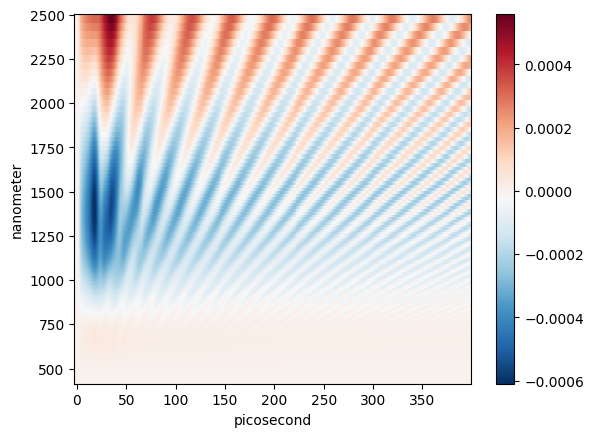

In [20]:
plt.figure()
plt.pcolormesh(delays, light.wl, (R_inhom[:, :, 0]-R_inhom[0, :, 0]).T, cmap='RdBu_r')

plt.colorbar()


plt.show()

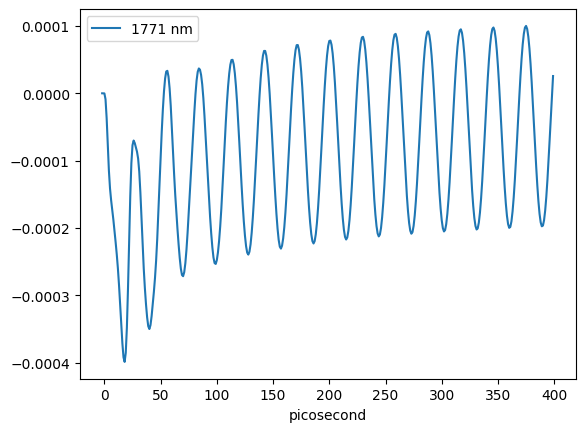

In [21]:
plt.figure()
idx = 20
plt.plot(delays, R_inhom[:, idx, 0].T-R_inhom[0, idx, 0].T, label=light.wl[idx])
plt.legend()
plt.show()